<a href="https://colab.research.google.com/github/JummerCloth/pupperv3-mjx/blob/CS123-group4-version/Pupper_MJX_CS_123_Group_4_rough_terrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Authors
Google (thanks Baruch!) + Nathan + Gabrael + Jaden

# GPU
If using the heightfield terrain (default) please use A100 GPU

# Log in to Weights and Biases

I recommend you use colab "secrets" (see key icon on the left) and add a secret "wandb_key" with your Weights & Biases API key. If you choose not to, you can enter the API key in the cell with wandb.login when it prompts you.

In [1]:
from google.colab import userdata
try:
  wandb_key = userdata.get('hf_key')
except userdata.SecretNotFoundError:
  wandb_key = 'bb2d262d02e5213ffe035ca13dda781b48478f6a'

In [2]:
!pip install -q wandb
import wandb
wandb.login(key=wandb_key if wandb_key else None)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

# Install dependencies

In [3]:
# !pip install mujoco --pre --upgrade -f https://py.mujoco.org/
# !pip install "mujoco-mjx @ git+git://github.com/google-deepmind/mujoco.git#subdirectory=mjx" -f https://py.mujoco.org/
!pip install -q mujoco
!pip install -q mujoco-mjx
!pip install -q brax

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.4/243.4 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 704.8/704.8 kB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 9.8 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
#@title Check if MuJoCo installation was successful

from google.colab import files

import distutils.util
import os
import subprocess
if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.')

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".')

print('Installation successful.')

Setting environment variable to use GPU rendering:
env: MUJOCO_GL=egl
Checking that the installation succeeded:
Installation successful.


## Install pupperv3-mjx

In [6]:
!rm -rf pupperv3_mjx
# !pip install git+https://github.com/Nate711/pupperv3-mjx.git
!git clone https://github.com/JummerCloth/pupperv3-mjx.git && mv pupperv3-mjx pupperv3_mjx

Cloning into 'pupperv3-mjx'...
remote: Enumerating objects: 554, done.
remote: Counting objects: 100% (240/240), done.
remote: Compressing objects: 100% (145/145), done.
remote: Total 554 (delta 142), reused 164 (delta 80), pack-reused 314 (from 1)
Receiving objects: 100% (554/554), 4.66 MiB | 20.39 MiB/s, done.
Resolving deltas: 100% (348/348), done.


In [7]:
!cd pupperv3_mjx && git checkout 14d8af0b30b75640185aacb37589b9ceafc5ed75 && pip install -q .

Note: switching to '14d8af0b30b75640185aacb37589b9ceafc5ed75'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 14d8af0 added obstacles
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.5 MB/s eta 0:00:00


In [8]:
#@title Import packages
import time
import itertools
import numpy as np
from typing import Callable, NamedTuple, Optional, Union, List

# Graphics and plotting.
print('Installing mediapy:')
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

from pupperv3_mjx import domain_randomization

import importlib

importlib.reload(domain_randomization)


Installing mediapy:


<module 'pupperv3_mjx.domain_randomization' from '/usr/local/lib/python3.10/dist-packages/pupperv3_mjx/domain_randomization.py'>

In [9]:
#@title Import MuJoCo, MJX, and Brax


from datetime import datetime
import functools
from IPython.display import HTML
import jax
from jax import numpy as jp
import numpy as np
from typing import Any, Dict, Sequence, Tuple, Union

from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.envs.base import Env, PipelineEnv, State
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import train as ppo
from brax.training.agents.ppo import networks as ppo_networks
from brax.io import html, mjcf, model

from etils import epath
from flax import struct
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx

## Download model

In [10]:
model_repo = 'https://github.com/g-levine/pupper_v3_description'
# model_repo = 'https://github.com/btaba/pupper_v3_description'
!rm -rf pupper_v3_description
!git clone {model_repo}
!cd pupper_v3_description && git checkout 218f24acf67ee2b2f8a80fa50ae6e4e3a3247468
# !cd pupper_v3_description
# !cd && git checkout 218f24acf67ee2b2f8a80fa50ae6e4e3a3247468
# !ls

Cloning into 'pupper_v3_description'...
remote: Enumerating objects: 715, done.
remote: Counting objects: 100% (302/302), done.
remote: Compressing objects: 100% (140/140), done.
remote: Total 715 (delta 257), reused 200 (delta 162), pack-reused 413 (from 1)
Receiving objects: 100% (715/715), 14.62 MiB | 21.50 MiB/s, done.
Resolving deltas: 100% (533/533), done.
Note: switching to '218f24acf67ee2b2f8a80fa50ae6e4e3a3247468'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 218f24a add ros2_control.xacro files for

# Base Configs

## Simulation Config

In [65]:
# Pupper model configuration
def get_simulation_config():
  simulation_config = config_dict.ConfigDict()
  simulation_config.model_repo = model_repo
  simulation_config.original_model_path = 'pupper_v3_description/description/mujoco_xml/pupper_v3_complete.mjx.position.no_body.self_collision.xml'
  simulation_config.model_xml = epath.Path(simulation_config.original_model_path).read_text()
  simulation_config.model_path = "pupper_v3_description/description/mujoco_xml/model_with_obstacles.xml"

  simulation_config.upper_leg_body_names = ["leg_front_r_2", "leg_front_l_2", "leg_back_r_2", "leg_back_l_2"]
  simulation_config.lower_leg_body_names = ["leg_front_r_3", "leg_front_l_3", "leg_back_r_3", "leg_back_l_3"]
  simulation_config.foot_site_names = [
      "leg_front_r_3_foot_site",
      "leg_front_l_3_foot_site",
      "leg_back_r_3_foot_site",
      "leg_back_l_3_foot_site",
  ]
  simulation_config.foot_radius = 0.02
  simulation_config.torso_name = "base_link"

  # Collision detection
  simulation_config.max_contact_points = 5 # 8
  simulation_config.max_geom_pairs = 4 # 8

  # Joint limits
  # sys_temp = mjcf.load("pupper_v3_description/description/mujoco_xml/../meshes/stl/BodyV4v70_001.stl")
  sys_temp = mjcf.load(simulation_config.original_model_path)
  joint_upper_limits = sys_temp.jnt_range[1:, 1]
  joint_lower_limits = sys_temp.jnt_range[1:, 0]
  simulation_config.joint_upper_limits = np.array(joint_upper_limits).tolist()
  simulation_config.joint_lower_limits = np.array(joint_lower_limits).tolist()
  return simulation_config

## Training Config

In [66]:
def get_training_config():
  training_config = config_dict.ConfigDict()

  # Environment timestep
  training_config.environment_dt = 0.02

  # PPO params
  training_config.ppo = config_dict.ConfigDict()
  training_config.ppo.num_timesteps = 100_000_000  # originally 100M
  training_config.ppo.episode_length = 1000
  training_config.ppo.num_evals = 10
  training_config.ppo.reward_scaling = 1
  training_config.ppo.normalize_observations = True
  training_config.ppo.action_repeat = 1
  training_config.ppo.unroll_length = 20
  training_config.ppo.num_minibatches = 32
  training_config.ppo.num_updates_per_batch = 4
  training_config.ppo.discounting = 0.99
  training_config.ppo.learning_rate = 3.0e-4
  training_config.ppo.entropy_cost = 1e-2
  training_config.ppo.num_envs = 8192
  training_config.ppo.batch_size = 256

  # Randomization
  training_config.kick_probability = 0.0  # Kick the robot every this many frames
  training_config.kick_vel = 0.1  # Change the torso velocity by this much in random direction [m/s]
  training_config.obs_noise = 0.0

  # Command sampling
  training_config.resample_velocity_step = training_config.ppo.episode_length // 2
  training_config.lin_vel_x_range = [-1.0, 1.0]  # min max [m/s]
  training_config.lin_vel_y_range = [-0.5, 0.5]  # min max [m/s]
  training_config.ang_vel_yaw_range = [-2.0, 2.0]  # min max [rad/s]

  # Desired body orientation
  training_config.desired_world_z_in_body_frame = (0.0, 0.0, 1.0)

  # Termination
  training_config.terminal_body_z = -100.0  # [m]
  training_config.terminal_body_angle = 100.0  # 30 deg

  # Joint PD overrides
  training_config.dof_damping = 0.25  # [Nm / (rad/s)]
  training_config.position_control_kp = 5.0  # [Nm / rad]

  # Default joint angles
  training_config.default_pose = jp.array(
      [0.26, 0.0, -0.52, -0.26, 0.0, 0.52, 0.26, 0.0, -0.52, -0.26, 0.0, 0.52]
  )

  # Height field
  training_config.height_field_enable = True # Whether to use heightfield or not
  training_config.height_field_grid_size = 256
  training_config.height_field_group = "0"
  training_config.height_field_radius_x = 10.0 # [m]
  training_config.height_field_radius_y = 10.0 # [m]
  training_config.height_field_elevation_z = 0.09#0.000001 # [m]0.06
  training_config.height_field_base_z = 0.2 # [m]

  # Obstacles
  training_config.n_obstacles = 0
  training_config.obstacle_x_range = (-1.5, 1.5)  # [m]
  training_config.obstacle_y_range = (-1.5, 1.5)  # [m]
  training_config.obstacle_height = 0.04  # [m]
  training_config.obstacle_length = 6.0  # [m]


  # Domain randomization
  training_config.position_control_kp_multiplier_range = (1.0, 1.0)
  training_config.position_control_kd_multiplier_range = (1.0, 1.0)
  training_config.start_position_config = domain_randomization.StartPositionRandomization(
      x_min=-2.0, x_max=2.0, y_min=-2.0, y_max=2.0, z_min=0.15, z_max=0.20
  )

  ## Body CoM
  training_config.body_com_x_shift_range = (0.0, 0.0)
  training_config.body_com_y_shift_range = (-0.000, 0.000)
  training_config.body_com_z_shift_range = (-0.00, 0.00)

  # ## Mass and inertia randomization for all bodies
  training_config.body_mass_scale_range = (0.99, 1.01)
  training_config.body_inertia_scale_range = (0.99, 1.01)

  return training_config

## Policy config

In [67]:
def get_policy_config():
  policy_config = config_dict.ConfigDict()

  policy_config.observation_history = 2  # number of stacked observations to give the policy
  policy_config.action_scale = 0.75  # originally 0.3
  policy_config.hidden_layer_sizes = (128, 128, 128, 128)

  # RTNeural supports relu, tanh, sigmoid (not great), softmax, elu, prelu
  # Swish was really good in terms of training but not supported in RTNeural rn
  policy_config.activation = "elu"
  return policy_config

## Reward config

In [68]:
def get_reward_config():
  reward_config = config_dict.ConfigDict()
  reward_config.rewards = config_dict.ConfigDict()

  scales = config_dict.ConfigDict()

  scales.tracking_lin_vel = 0.0

  # Track the angular velocity along z-axis, i.e. yaw rate.
  scales.tracking_ang_vel = 0.0

  # Track the given body orientation (desired world z axis in body frame)
  # Not working right now
  scales.tracking_orientation = 0.0

  # Below are regularization terms, we roughly divide the
  # terms to base state regularizations, joint
  # regularizations, and other behavior regularizations.
  # Penalize the base velocity in z direction, L2 penalty.
  scales.lin_vel_z = 0.0

  # Penalize the base roll and pitch rate. L2 penalty.
  scales.ang_vel_xy = 0.0

  # Penalize non-zero roll and pitch angles. L2 penalty.
  scales.orientation = 0.0

  # L2 regularization of joint torques, sum(|tau|^2).
  scales.torques = -0.0

  # L2 regularization of joint accelerations sum(|qdd|^2)
  scales.joint_acceleration = 0.0

  # L1 regularization of mechanical work, |v * tau|.
  scales.mechanical_work = 0.0

  # Penalize the change in the action and encourage smooth
  # actions. L2 regularization |action - last_action|^2
  scales.action_rate = -0.0

  # Encourage long swing steps. However, it does not
  # encourage high clearances.
  scales.feet_air_time = 0.0

  # Encourage no motion at zero command, L2 regularization
  # |q - q_default|^2.
  scales.stand_still = -0.0

  # Early termination penalty.
  scales.termination = 0.0

  # Penalizing foot slipping on the ground.
  scales.foot_slip = -0.0

  # Penalize knees hitting the ground
  scales.knee_collision = 0.0

  # Penalize body hitting ground
  scales.body_collision = -0.0

  reward_config.rewards.scales = scales

  # Tracking reward = exp(-error^2/sigma).
  reward_config.rewards.tracking_sigma = 0.25
  return reward_config

##Export config

In [69]:
# Define the path to the subdirectory
def get_export_config():
  export_config = config_dict.ConfigDict()
  export_config.gdrive_save_dir = '/content/drive/MyDrive/pupper_policies'
  return export_config

## Github repo config

In [70]:
import subprocess

def get_repo_config():
  def get_hash():
    return subprocess.check_output(['git', 'rev-parse', 'HEAD']).strip().decode('utf-8')

  repo_config = config_dict.ConfigDict()
  %cd /content/pupperv3_mjx
  repo_config.pupperv3_mjx_hash = get_hash()
  %cd /content/pupper_v3_description
  repo_config.pupper_v3_description_hash = get_hash()
  %cd /content
  return repo_config

# **Gather configs and update the configs you need to modify**

In [71]:
simulation_config = get_simulation_config()
training_config = get_training_config()
policy_config = get_policy_config()
reward_config = get_reward_config()
export_config = get_export_config()
repo_config = get_repo_config()

/content/pupperv3_mjx
/content/pupper_v3_description
/content


## Update the configs (what you need to change)
* You can find the reward implementations here: https://github.com/Nate711/pupperv3-mjx/blob/main/pupperv3_mjx/rewards.py
* Read and understand the implementations will help you tune the weights of different terms

In [80]:
#############################################
# Reward parameters
#############################################

# Track the linear velocity along x-axis
reward_config.rewards.scales.tracking_lin_vel = 1.5

# Track the angular velocity along z-axis, i.e. yaw rate.
reward_config.rewards.scales.tracking_ang_vel = 0.8

# Track the given body orientation (desired world z axis in body frame)
reward_config.rewards.scales.tracking_orientation = 1.

# Below are regularization terms, we roughly divide the
# terms to base state regularizations, joint
# regularizations, and other behavior regularizations.
# Penalize the base velocity in z direction, L2 penalty.
reward_config.rewards.scales.lin_vel_z = -2.

# Penalize the base roll and pitch rate. L2 penalty.
reward_config.rewards.scales.ang_vel_xy = -0.05

# Penalize non-zero roll and pitch angles. L2 penalty.
reward_config.rewards.scales.orientation = -5.

# L2 regularization of joint torques, sum(|tau|^2).
reward_config.rewards.scales.torques = -0.0002

# L2 regularization of joint accelerations sum(|qdd|^2)
reward_config.rewards.scales.joint_acceleration = -1e-6

# L1 regularization of mechanical work, |v * tau|.
reward_config.rewards.scales.mechanical_work = 0

# Penalize the change in the action and encourage smooth
# actions. L2 regularization |action - last_action|^2
reward_config.rewards.scales.action_rate = -0.01

# Encourage long swing steps. However, it does not
# encourage high clearances.
reward_config.rewards.scales.feet_air_time = 0.2

# Encourage no motion at zero command, L2 regularization
# |q - q_default|^2.
reward_config.rewards.scales.stand_still = -0.5

# Early termination penalty.
reward_config.rewards.scales.termination = -100

# Penalizing foot slipping on the ground.
reward_config.rewards.scales.foot_slip = -0.1

# Penalize knees hitting the ground
reward_config.rewards.scales.knee_collision = -1.0

# Penalize body hitting ground
reward_config.rewards.scales.body_collision = -1.0

#############################################
# Training configs
#############################################
training_config.kick_probability = 0.0  # Kick the robot every this many frames
training_config.kick_vel = 0.1  # Change the torso velocity by this much in random direction [m/s]
training_config.obs_noise = 0.0
training_config.lin_vel_x_range = [-1.0, 1.0]  # min max [m/s]
training_config.lin_vel_y_range = [-0.5, 0.5]  # min max [m/s]
training_config.ang_vel_yaw_range = [-1.0, 1.0]  # min max [rad/s]
training_config.terminal_body_z = 0.02  # [m]
training_config.terminal_body_angle = 0.5  # rad

#############################################
# # Domain randomization configs
#############################################
training_config.position_control_kp_multiplier_range = (1.0, 1.0)
training_config.position_control_kd_multiplier_range = (1.0, 1.0)
training_config.start_position_config = domain_randomization.StartPositionRandomization(
    x_min=-1.0, x_max=0., y_min=-2.0, y_max=2.0, z_min=0.2, z_max=0.25
)

## Body CoM
training_config.body_com_x_shift_range = (0.0, 0.0)
training_config.body_com_y_shift_range = (-0.000, 0.000)
training_config.body_com_z_shift_range = (-0.00, 0.00)

# ## Mass and inertia randomization for all bodies
training_config.body_mass_scale_range = (0.99, 1.01)
training_config.body_inertia_scale_range = (0.99, 1.01)

## Create aggregated config (be sure to run this after you change the config)

In [81]:
temp_config = config_dict.ConfigDict()
temp_config.simulation = simulation_config
temp_config.training = training_config
temp_config.policy = policy_config
temp_config.reward = reward_config
temp_config.export = export_config
temp_config.repo = repo_config

CONFIG = config_dict.FrozenConfigDict(temp_config)

sys = mjcf.load(CONFIG.simulation.model_path)

# Prevent user from accidentally making changes to these configs which are not used
del temp_config

# Modify robot model

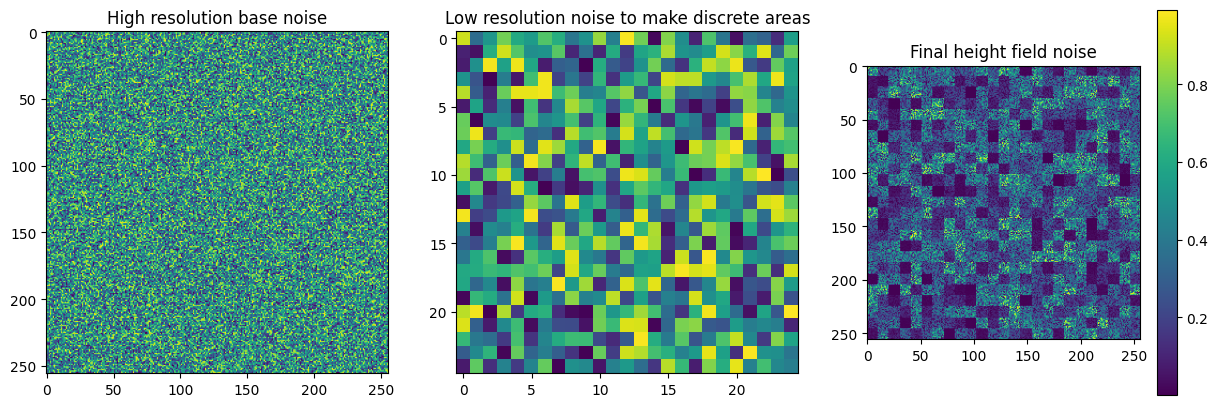

In [82]:
import xml.etree.ElementTree as ET
from pupperv3_mjx import utils
from pupperv3_mjx import obstacles
import importlib
importlib.reload(utils)
importlib.reload(obstacles)

# Set contact points
xml_str = epath.Path(CONFIG.simulation.original_model_path).read_text()
tree = ET.ElementTree(ET.fromstring(xml_str))
tree = utils.set_mjx_custom_options(tree,
                                    max_contact_points=CONFIG.simulation.max_contact_points,
                                    max_geom_pairs=CONFIG.simulation.max_geom_pairs)

# Add obstacles
tree = obstacles.add_boxes_to_model(
    tree,
    n_boxes=CONFIG.training.n_obstacles,
    x_range=CONFIG.training.obstacle_x_range,
    y_range=CONFIG.training.obstacle_y_range,
    height=CONFIG.training.obstacle_height,
    length=CONFIG.training.obstacle_length
)
'''
tree = obstacles.add_stairs_to_model(
    tree,
    1,
    stair_width = 10,
)
'''


#tree = obstacles.add_blocks_to_model(tree, 15)

# Add heightfield ground
if CONFIG.training.height_field_enable:
  # Height field with 8cm resolution
  noise = np.array(jax.random.uniform(jax.random.PRNGKey(0), (CONFIG.training.height_field_grid_size, CONFIG.training.height_field_grid_size)))

  # Height field with 1m resolution
  area_noise = jax.random.uniform(jax.random.PRNGKey(1),
   (int(CONFIG.training.height_field_grid_size//CONFIG.training.height_field_radius_x),
    int(CONFIG.training.height_field_grid_size//CONFIG.training.height_field_radius_y)))
  upscaled_area_noise = np.array(jax.image.resize(image=area_noise,
                                                  shape=(CONFIG.training.height_field_grid_size, CONFIG.training.height_field_grid_size),
                                                  method="nearest"))
  # Height field where
  scaled_noise = noise * upscaled_area_noise

  root = tree.getroot()
  worldbody = root.find("worldbody")
  asset = root.find("asset")

  ET.SubElement(
      asset,
      "hfield",
      name="hfield_geom",
      # pos="0 0 0",
      nrow=f"{CONFIG.training.height_field_grid_size}",
      ncol=f"{CONFIG.training.height_field_grid_size}",
      elevation = ' '.join(scaled_noise.astype(str).flatten().tolist()),
      size=f"{CONFIG.training.height_field_radius_x} {CONFIG.training.height_field_radius_y} {CONFIG.training.height_field_elevation_z} {CONFIG.training.height_field_base_z}",
  )

  ET.SubElement(
      worldbody,
      "geom",
      name="hfield_floor",
      type="hfield",
      hfield="hfield_geom",
      # rgba="0.1 0.5 0.8 1",
      material="grid",
      conaffinity="1",
      contype="1",
      condim="3",
      group=CONFIG.training.height_field_group,
  )
  fig, axs = plt.subplots(1, 3, figsize=(15, 5))

  axs[0].imshow(noise, cmap='viridis')
  axs[0].set_title('High resolution base noise')
  axs[1].imshow(area_noise, cmap='viridis')
  axs[1].set_title('Low resolution noise to make discrete areas')
  im = axs[2].imshow(scaled_noise, cmap='viridis')
  axs[2].set_title('Final height field noise')
  fig.colorbar(im, orientation='vertical')

## Write new model

In [83]:
with open(CONFIG.simulation.model_path,'w+') as file:
  tree.write(file, encoding='unicode')

# Benchmark pupper model (Optional)


In [ ]:
from mujoco.mjx import benchmark
jit_time, run_time, steps = benchmark(sys.mj_model, batch_size=CONFIG.training.ppo.num_envs)
print('Steps per sec: ', steps / run_time)

Steps per sec:  3341157.133487771


<!-- ## Save and Load Policy -->

We can save and load the policy using the brax model API.

# Pupper V3 Env



## Create Pupper V3 Env


In [84]:
from pupperv3_mjx import environment
import importlib
importlib.reload(environment)

envs.register_environment('pupper', environment.PupperV3Env)

env_kwargs = dict(path=CONFIG.simulation.model_path,
                  desired_world_z_in_body_frame=jp.array(CONFIG.training.desired_world_z_in_body_frame),
                  action_scale=CONFIG.policy.action_scale,
                  observation_history=CONFIG.policy.observation_history,
                  dof_damping=CONFIG.training.dof_damping,
                  position_control_kp=CONFIG.training.position_control_kp,
                  kick_vel = CONFIG.training.kick_vel,
                  kick_probability = CONFIG.training.kick_probability,
                  motor_angle_noise=CONFIG.training.obs_noise,
                  resample_velocity_step=CONFIG.training.resample_velocity_step,
                  linear_velocity_x_range=CONFIG.training.lin_vel_x_range,
                  linear_velocity_y_range=CONFIG.training.lin_vel_y_range,
                  angular_velocity_range=CONFIG.training.ang_vel_yaw_range,
                  default_pose=CONFIG.training.default_pose,
                  foot_site_names = CONFIG.simulation.foot_site_names,
                  joint_lower_limits=np.array(CONFIG.simulation.joint_lower_limits),
                  joint_upper_limits=np.array(CONFIG.simulation.joint_upper_limits),
                  torso_name=CONFIG.simulation.torso_name,
                  upper_leg_body_names=CONFIG.simulation.upper_leg_body_names,
                  lower_leg_body_names=CONFIG.simulation.lower_leg_body_names,
                  start_position_config=CONFIG.training.start_position_config,
                  terminal_body_angle=CONFIG.training.terminal_body_angle,
                  terminal_body_z=CONFIG.training.terminal_body_z,
                  reward_config=CONFIG.reward)
env_name = 'pupper'
env = envs.get_environment(env_name, **env_kwargs)


## Visualize single env

In [58]:
visualization_env = envs.get_environment(env_name, **env_kwargs)

# initialize the state
rng = jax.random.PRNGKey(1)

jit_reset = jax.jit(visualization_env.reset)
jit_step = jax.jit(visualization_env.step)

state = jit_reset(rng)
state.info['command'] = jp.array([0, 0, 0])

rollout = [state.pipeline_state]

# grab a trajectory
n_steps = 200
render_every = 2

for i in range(n_steps):
  act_rng, rng = jax.random.split(rng)
  ctrl = jp.array(np.random.uniform(low=-1.0, high=1.0, size=sys.nu))*0.5
  state = jit_step(state, ctrl)
  rollout.append(state.pipeline_state)

media.show_video(
    visualization_env.render(rollout[::render_every], camera='tracking_cam'),
    fps=1.0 / visualization_env.dt / render_every)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


This browser does not support the video tag.


# Train Policy


JIT'd step and reset functions already defined. Using them for policy visualization.


/usr/local/lib/python3.10/dist-packages/pupperv3_mjx/domain_randomization.py:82: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  in_axes = jax.tree_map(lambda x: None, sys)
/usr/local/lib/python3.10/dist-packages/pupperv3_mjx/domain_randomization.py:82: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  in_axes = jax.tree_map(lambda x: None, sys)


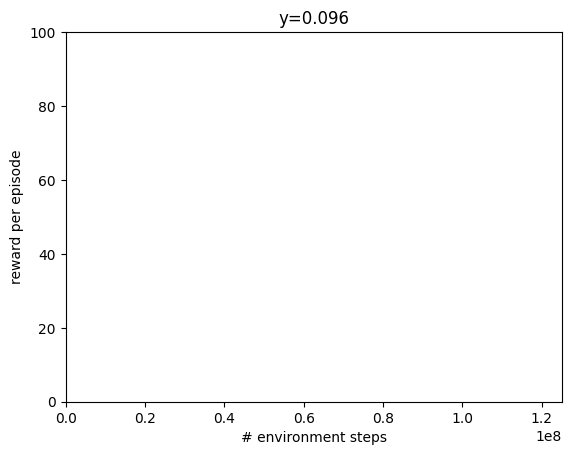

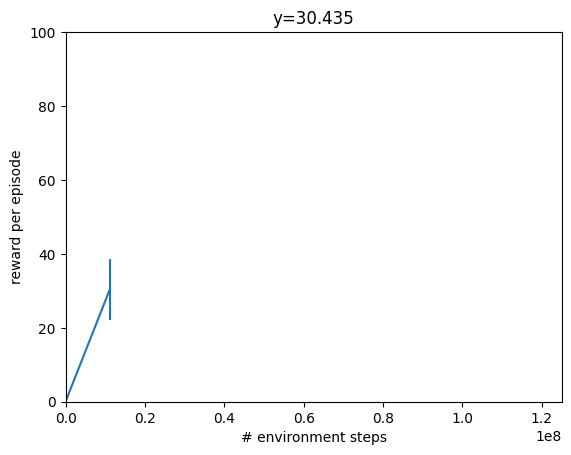

wandb: WARNING `fps` argument does not affect the frame rate of the video when providing a file path or raw bytes.


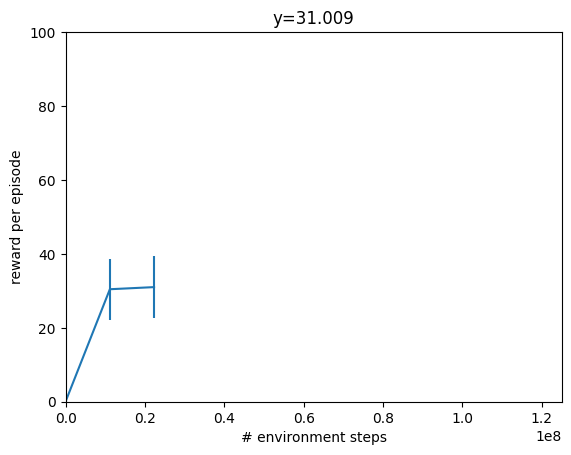

wandb: WARNING `fps` argument does not affect the frame rate of the video when providing a file path or raw bytes.


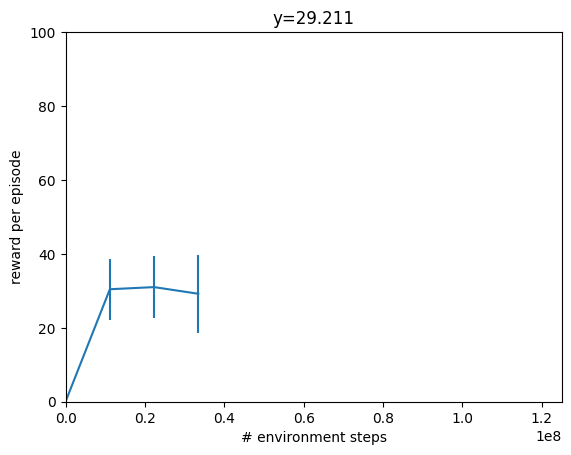

wandb: WARNING `fps` argument does not affect the frame rate of the video when providing a file path or raw bytes.


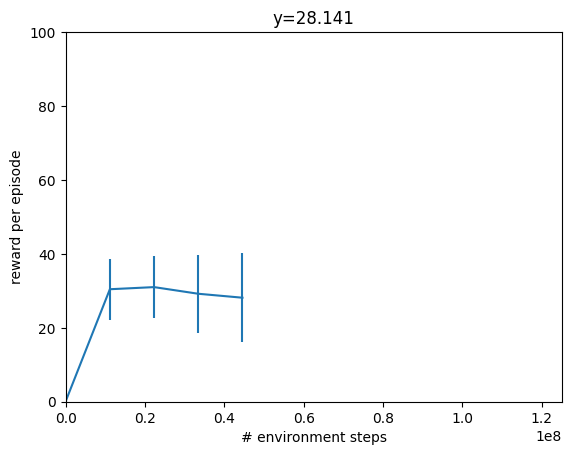

wandb: WARNING `fps` argument does not affect the frame rate of the video when providing a file path or raw bytes.


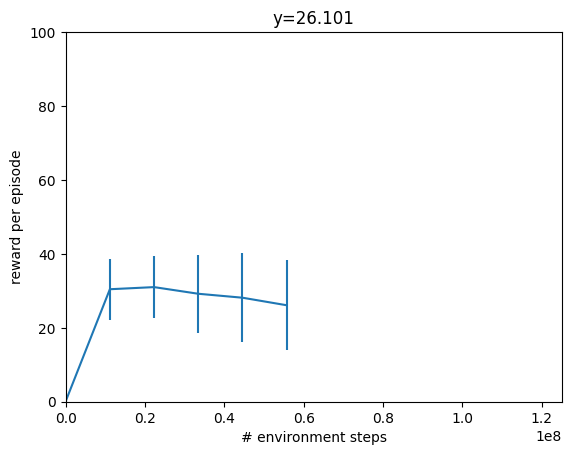

wandb: WARNING `fps` argument does not affect the frame rate of the video when providing a file path or raw bytes.


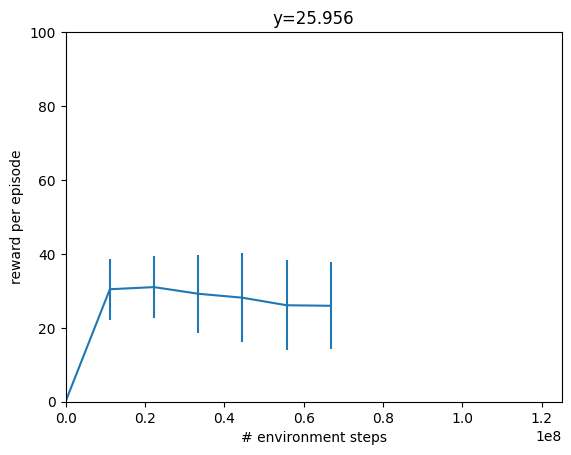

wandb: WARNING `fps` argument does not affect the frame rate of the video when providing a file path or raw bytes.


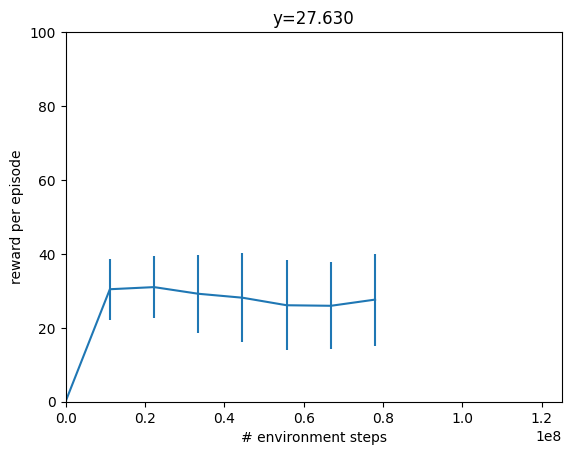

wandb: WARNING `fps` argument does not affect the frame rate of the video when providing a file path or raw bytes.


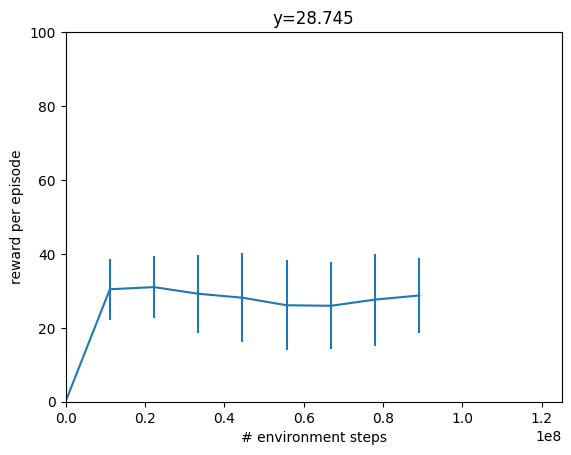

wandb: WARNING `fps` argument does not affect the frame rate of the video when providing a file path or raw bytes.


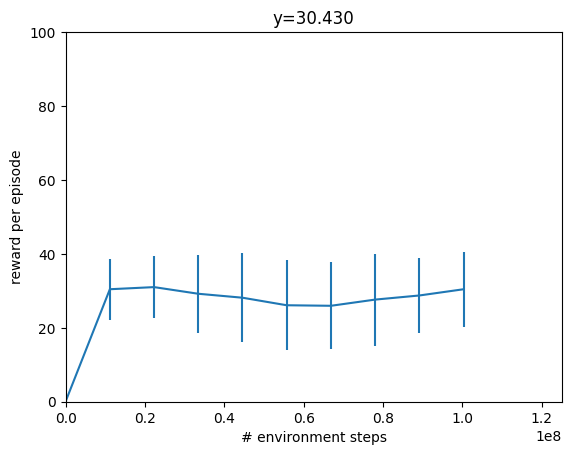

wandb: WARNING `fps` argument does not affect the frame rate of the video when providing a file path or raw bytes.


time to jit: 0:01:20.974288
time to train: 0:08:07.327295


In [85]:
from datetime import datetime
from pupperv3_mjx import utils
import importlib

importlib.reload(utils)

train_datetime = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

wandb.init(project="pupperv3-mjx-rl", config=CONFIG.to_dict(), save_code=True)

# Save and reload params.
output_folder = f"output_{wandb.run.name}"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Create and JIT reset and step functions for use in in-training policy
# video creation if they don't already exist from a previous step
if ("jit_reset" in globals() or "jit_reset" in locals()) and (
    "jit_step" in globals() or "jit_step" in locals()
):
    print("JIT'd step and reset functions already defined. " "Using them for policy visualization.")
else:
    print("Creating and JIT'ing step and reset functions")
    policy_viz_env = envs.get_environment(env_name, **env_kwargs)
    jit_reset = jax.jit(policy_viz_env.reset)
    jit_step = jax.jit(policy_viz_env.step)


make_networks_factory = functools.partial(
    ppo_networks.make_ppo_networks,
    policy_hidden_layer_sizes=CONFIG.policy.hidden_layer_sizes,
    activation=utils.activation_fn_map(CONFIG.policy.activation)
)
train_fn = functools.partial(
    ppo.train,
    **(CONFIG.training.ppo.to_dict()),
    network_factory=make_networks_factory,
    randomization_fn=functools.partial(
        domain_randomization.domain_randomize,
        kp_multiplier_range=CONFIG.training.position_control_kp_multiplier_range,
        kd_multiplier_range=CONFIG.training.position_control_kd_multiplier_range,
        body_com_x_shift_range=CONFIG.training.body_com_x_shift_range,
        body_com_y_shift_range=CONFIG.training.body_com_y_shift_range,
        body_com_z_shift_range=CONFIG.training.body_com_z_shift_range,
        body_mass_scale_range=CONFIG.training.body_mass_scale_range,
        body_inertia_scale_range=CONFIG.training.body_inertia_scale_range,
    ),
    seed=0,
)

x_data = []
y_data = []
ydataerr = []
times = [datetime.now()]

env = envs.get_environment(env_name, **env_kwargs)
eval_env = envs.get_environment(env_name, **env_kwargs)

make_inference_fn, params, _ = train_fn(
    environment=env,
    progress_fn=functools.partial(
        utils.progress,
        times=times,
        x_data=x_data,
        y_data=y_data,
        ydataerr=ydataerr,
        num_timesteps=CONFIG.training.ppo.num_timesteps,
        min_y=0,
        max_y=100,
    ),
    eval_env=eval_env,
    policy_params_fn=functools.partial(
        utils.visualize_policy,
        eval_env=eval_env,
        jit_step=jit_step,
        jit_reset=jit_reset,
        output_folder=output_folder,)
)

print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")


In [60]:
model_path = os.path.join(output_folder, f'mjx_params_{train_datetime}')
model.save_params(model_path, params)
# params = model.load_params(model_path)
print(model_path)



output_charmed-field-51/mjx_params_2024-12-09_00-32-00


In [61]:
inference_fn = make_inference_fn(params)
jit_inference_fn = jax.jit(inference_fn)

# Visualize Policy

For the Pupper Quadruped, the joystick commands can be set through `x_vel`, `y_vel`, and `ang_vel`. `x_vel` and `y_vel` define the linear forward and sideways velocities with respect to the quadruped torso. `ang_vel` defines the angular velocity of the torso in the z direction.

In [62]:
eval_env = envs.get_environment(env_name, **env_kwargs)

In [63]:
# @markdown Commands **only used for Pupper Env**:
x_vel = .75  #@param {type: "number"}
y_vel = 0  #@param {type: "number"}
ang_vel = 0  #@param {type: "number"}

the_command = jp.array([x_vel, y_vel, ang_vel])

# initialize the state
rng = jax.random.PRNGKey(0)
state = jit_reset(rng)
state.info['command'] = the_command
rollout = [state.pipeline_state]

# grab a trajectory
n_steps = 400
render_every = 2
ctrls = []

for i in range(n_steps):
  act_rng, rng = jax.random.split(rng)

  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_step(state, ctrl)
  rollout.append(state.pipeline_state)
  ctrls.append(ctrl)

media.show_video(
    eval_env.render(rollout[::render_every], camera='tracking_cam'),
    fps=1.0 / eval_env.dt / render_every)

This browser does not support the video tag.


# Export Policy for neural_controller

After running the following cells, open the files tab on the left and download `output_{projname}/xxxx_policy.json.`

In [50]:
import json
from pupperv3_mjx import export
params_rtneural = export.convert_params(jax.block_until_ready(params),
                                        action_scale=CONFIG.policy.action_scale,
                                        kp=CONFIG.training.position_control_kp,
                                        kd=CONFIG.training.dof_damping,
                                        default_pose=CONFIG.training.default_pose,
                                        upper_limits=CONFIG.simulation.joint_upper_limits,
                                        lower_limits=CONFIG.simulation.joint_lower_limits,
                                        activation=CONFIG.policy.activation,
                                        final_activation="tanh")

name = f"policy_{wandb.run.name}_max_reward_{y_data[-1]:0.2f}.json"
saved_policy_filename = os.path.join(output_folder, name)
with open(saved_policy_filename, "w") as f:
  json.dump(params_rtneural, f)
# os.makedirs(model_path)
print(saved_policy_filename)
wandb.log_model(path=saved_policy_filename, name=name)
wandb.log_model(path=model_path, name=f"mjx_policy_network_{wandb.run.name}.pt")
print(model_path, f"mjx_policy_network_{wandb.run.name}.pt")
print(saved_policy_filename)


output_generous-resonance-48/policy_generous-resonance-48_max_reward_114.03.json
output_generous-resonance-48/mjx_params_2024-12-07_21-28-17 mjx_policy_network_generous-resonance-48.pt
output_generous-resonance-48/policy_generous-resonance-48_max_reward_114.03.json


In [79]:
wandb.finish()

eval/avg_episode_length,▁██████
eval/episode_action_rate,█▁▅▇▇▆▅
eval/episode_action_rate_std,█▄▄▂▁▃▃
eval/episode_ang_vel_xy,▆▁▄██▅▂
eval/episode_ang_vel_xy_std,█▁▂▁▁▃▃
eval/episode_body_collision,▁▁▁▁▁▁▁
eval/episode_body_collision_std,▁▁▁▁▁▁▁
eval/episode_feet_air_time,▁▅▇▇▇▇█
eval/episode_feet_air_time_std,▁▆▇▇██▇
eval/episode_foot_slip,▇▁▃▆█▅▅
eval/episode_foot_slip_std,█▇▄▃▁▂▃


#Save outputs to GDrive

In [ ]:
output_folder

'output_celestial-elevator-38'

In [ ]:
# !ls {GDRIVE_SAVE_DIR}

# Shutdown the runtime to save money

In [ ]:
# Give time for wandb to actually finish?
import time
time.sleep(10)

# Helpful for overnight runs
from google.colab import runtime
runtime.unassign()